In [1]:
# Ensure working directory to project code folder
import os

os.chdir("/ceph/behrens/peter_doohan/goalNav_mFC/experiment/code")
print("Current Working Directory: ", os.getcwd())

from importlib import reload

Current Working Directory:  /ceph/behrens/peter_doohan/goalNav_mFC/experiment/code


In [2]:
# configure matplotlib settings

from matplotlib import pyplot as plt

plt.rcParams.update(
    {
        "font.size": 12,
        "axes.titlesize": 16,
        "axes.labelsize": 14,
        "xtick.labelsize": 14,
        "ytick.labelsize": 14,
        "legend.fontsize": 8,
        "figure.titlesize": 18,
        "pdf.fonttype": 42,
    }
)
from matplotlib.gridspec import GridSpec

In [ ]:
from GridMaze.analysis.distance_to_goal import distance_metrics as dm

reload(dm)
cpd_summary_df = dm.get_distance_metric_CPD_summary_df(verbose=False)
weights_summary_df = dm.get_weight_metrics_summary_df(verbose=False)

Main figures (prelim)

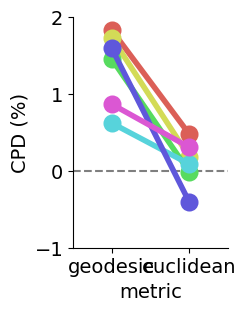

In [17]:
reload(dm)
f, ax = plt.subplots(1, 1, figsize=(2, 3))
dm.plot_cross_subject_CPD_comparison(
    cpd_summary_df, comparison="geodesic_vs_euclidean", maze_names=["maze_1", "maze_2"], late_sessions=True, ax=ax
)
f.savefig("../results/distance_to_goal/figures/cpd_comparison_geodesic_vs_euclidean.pdf")

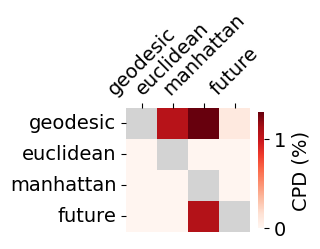

In [5]:
dm.plot_pairwise_CPD_summary(cpd_summary_df, late_sessions=True, maze_names=["maze_1", "maze_2"])

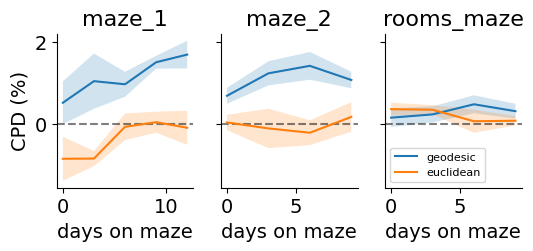

In [6]:
dm.plot_CPD_timeseries(cpd_summary_df, comparison="geodesic_vs_euclidean", group_days=3)

Supp figures (prelim)

geodesic_vs_euclidean: L1_ratio t-stat: -4.541, p-value: 6.162e-03


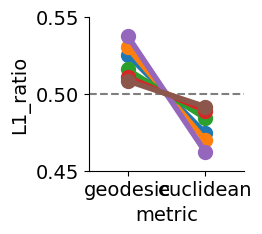

In [7]:
dm.plot_cross_subject_norm_comparison(
    weights_summary_df, comparison="geodesic_vs_euclidean", maze_names=["maze_1", "maze_2"], late_sessions=True
)

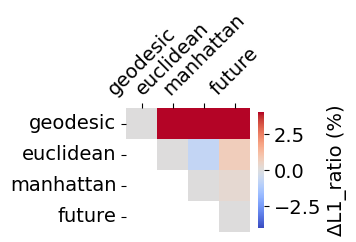

In [8]:
dm.plot_all_pairwise_metric_norm_diffs(
    weights_summary_df, norm_metric="L1_ratio", late_sessions=True, maze_names=["maze_1", "maze_2"]
)

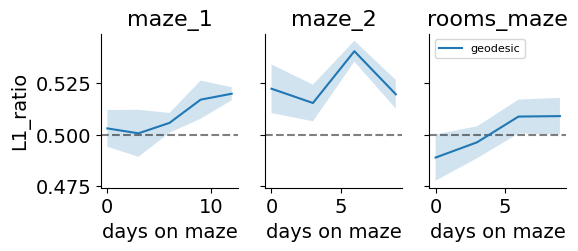

In [9]:
dm.plot_weights_comparison_timeseries(
    weights_summary_df, comparison="geodesic_vs_euclidean", plot_metric="geodesic", group_days=3
)

Characterising population tuning to distance to goal

In [19]:
from GridMaze.analysis.distance_to_goal import population_tuning as pt

In [20]:
fit_summary_df = pt.get_tuning_fits_summary_df()

clusters.distanceTuningMetrics.parquet not found for m8.2022-07-26.maze


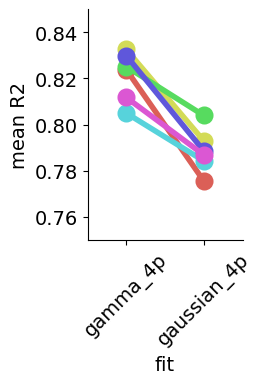

In [21]:
reload(pt)
f, ax = plt.subplots(1, 1, figsize=(2, 3))
pt.plot_cross_subject_curve_fit_comparison(fit_summary_df, curve_fits=["gamma_4p", "gaussian_4p"], ax=ax)
ax.set_ylim(0.75, 0.85)
f.savefig("../results/distance_to_goal/figures/gamma_vs_gaussian.pdf")

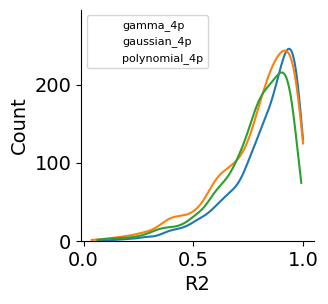

In [11]:
pt.plot_curve_fit_distributions(fit_summary_df)

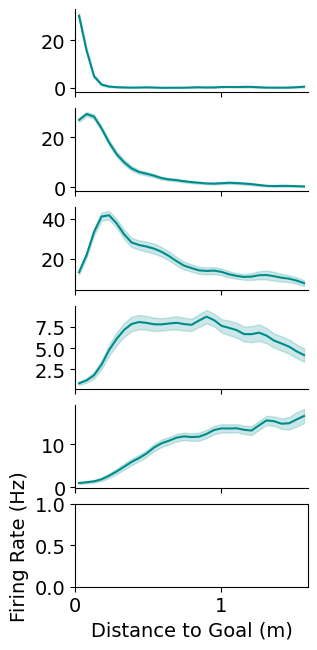

In [ ]:
# plot some individual units
from GridMaze.analysis.cluster_tuning import distance_to_goal as dtg
from GridMaze.analysis.core import get_clusters as gc

reload(dtg)
reload(gc)

example_clusters = [
    "m2.2022-07-03.maze_cluster43",
    "m3.2022-07-02.maze_cluster44",
    "m2.2022-07-03.maze_cluster9",
    "m3.2022-07-01.maze_cluster38",
    "m3.2022-07-16.maze_cluster137",
]

Clusters = [gc.get_cluster(cluster) for cluster in example_clusters]

f_units_pos, axes = plt.subplots(6, 1, figsize=(3, 7.5), sharex=True)

for cluster, ax in zip(example_clusters, axes.flatten()):
    Cluster = gc.get_cluster(cluster)
    Cluster.plot_tuning(feature="distance_to_goal", ax=ax)
    ax.set_xlabel("")
    ax.set_ylabel("")
axes[-1].set_xlabel("Distance to Goal (m)")
axes[-1].set_ylabel("Firing Rate (Hz)")

# f_units_pos.savefig("../results/distance_to_goal/figures/example_units_pos.pdf")

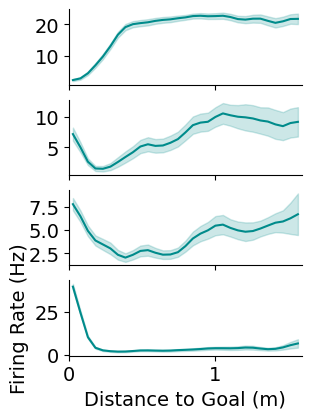

In [44]:
example_clusters = [
    "m7.2022-07-03.maze_cluster54",
    "m2.2022-07-13.maze_cluster99",
    "m3.2022-07-24.maze_cluster16",
    "m7.2022-07-11.maze_cluster28",
]

f_units_neg, axes = plt.subplots(4, 1, figsize=(3, 4.5), sharex=True)

for cluster, ax in zip(example_clusters, axes.flatten()):
    Cluster = gc.get_cluster(cluster)
    Cluster.plot_tuning(feature="distance_to_goal", ax=ax)
    ax.set_xlabel("")
    ax.set_ylabel("")
axes[-1].set_xlabel("Distance to Goal (m)")
axes[-1].set_ylabel("Firing Rate (Hz)")

f_units_neg.savefig("../results/distance_to_goal/figures/example_units_neg.pdf")

In [22]:
# get data to plot distance tuning heatmaps
population_tuning_df = pt.get_population_tuning_df(late_sessions=False)

frames.navigation.parquet not found for m3.2022-06-25.maze
frames.spikeRates.parquet not found for m3.2022-06-25.maze
clusters.metrics.htsv not found for m3.2022-06-25.maze
clusters.distanceTuningMetrics.parquet not found for m3.2022-06-25.maze
frames.navigation.parquet not found for m8.2022-07-26.maze
frames.spikeRates.parquet not found for m8.2022-07-26.maze
clusters.distanceTuningMetrics.parquet not found for m8.2022-07-26.maze


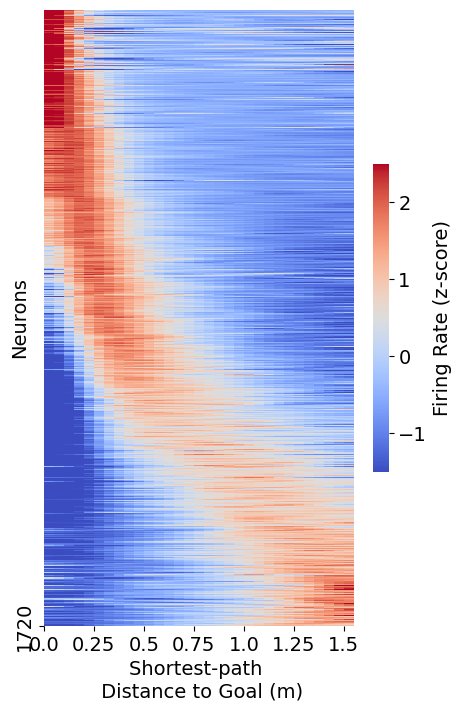

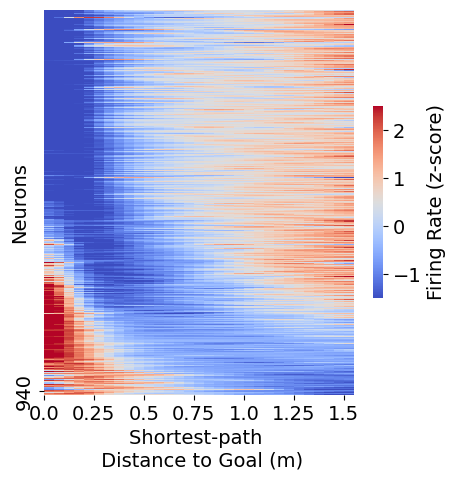

In [23]:
f_hm_pos, ax1 = plt.subplots(1, 1, figsize=(5, 8))
reload(pt)
pt.plot_distance_tunned_heatmap(population_tuning_df, sign="pos", ax=ax1, cmap="coolwarm", v_range=(-1.5, 2.5))
f_hm_pos.savefig("../results/distance_to_goal/figures/distance_tuning_heatmap_pos.pdf")

f_hm_neg, ax2 = plt.subplots(1, 1, figsize=(5, 5))
pt.plot_distance_tunned_heatmap(population_tuning_df, sign="neg", ax=ax2, cmap="coolwarm", v_range=(-1.5, 2.5))
f_hm_neg.savefig("../results/distance_to_goal/figures/distance_tuning_heatmap_neg.pdf")

In [ ]:
# get distance to goal decoding results
# what can we read out from these tuning curves? how good is the distance decoding at longer distances
from GridMaze.analysis.distance_to_goal import logreg_decoder as ld

results_df = ld.load_decoding_results(subfolder="all_dist")

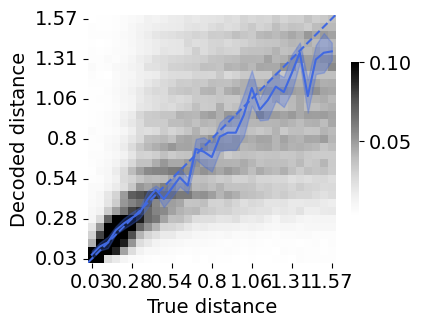

In [5]:
reload(ld)
f, ax = plt.subplots(1, 1, figsize=(4, 4))
ld.plot_distance_decoding_probs(results_df, moving_only=True, ax=ax)

In [18]:
# is there any theta modulation in this signal?
from GridMaze.analysis.lfp import theta_mod as tm
from GridMaze.analysis.distance_to_goal import theta_mod_decoder as tmd

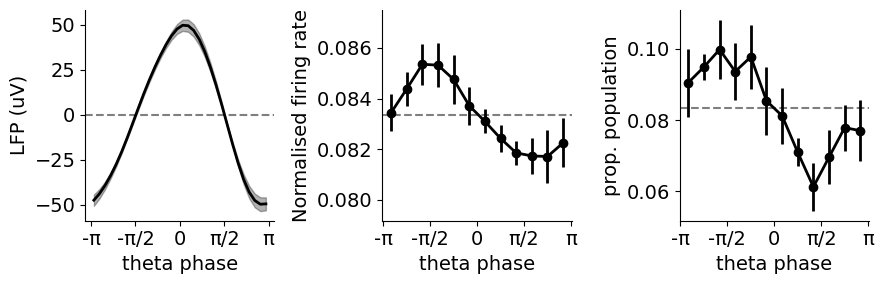

In [14]:
# similar to previous work we see the mFC cells are modulated by theta phase
reload(tm)
theta_aligned_signal = tm.get_theta_aligned_lfp_df()
population_theta_df = tm.get_population_theta_mod()
f, axes = plt.subplots(1, 3, figsize=(9, 3))
tm.plot_theta_aligned_lfp(theta_aligned_signal, ax=axes[0])
tm.plot_population_theta_mod(population_theta_df, ax=axes[1])
tm.plot_population_theta_pref(population_theta_df, ax=axes[2])
f.tight_layout()

In [23]:
reload(tmd)
theta_mod_decoding = tmd.load_decoding_results(lfp_type="theta_mid")

                  T2         F  df1  df2      pval
hotelling  16.323042  7.345369    2    9  0.012838


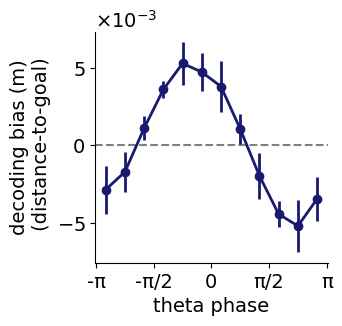

In [21]:
f, ax = plt.subplots(1, 1, figsize=(3, 3))
tmd.plot_decoding_theta_bias(theta_mod_decoding, ax=ax, print_stats=True)

In [3]:
# lets look at theta modulation in another way: tuning curves
from GridMaze.analysis.distance_to_goal import theta_mod_tuning as tmt

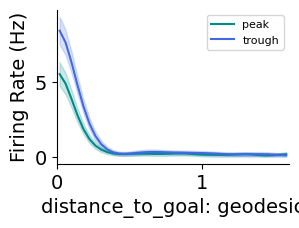

In [27]:
from GridMaze.analysis.core import get_clusters as gc

reload(gc)
Cluster = gc.get_cluster("m2.2022-07-04.maze_cluster34")
f, ax = plt.subplots(1, 1, figsize=(3, 2))
Cluster.plot_tuning(feature="distance_to_goal_theta", ax=ax)

In [4]:
# load all distance tuning curves split by theta phase (peak and trough)
tuning_curves, tuning_metrics = tmt.get_population_theta_split_distance_tuning(verbose=False)

frames.navigation.parquet not found for m3.2022-06-25.maze
frames.thetaSpikeCounts.parquet not found for m3.2022-06-25.maze
clusters.distanceTuningMetrics.parquet not found for m3.2022-06-25.maze
frames.navigation.parquet not found for m8.2022-07-26.maze
frames.thetaSpikeCounts.parquet not found for m8.2022-07-26.maze
clusters.distanceTuningMetrics.parquet not found for m8.2022-07-26.maze


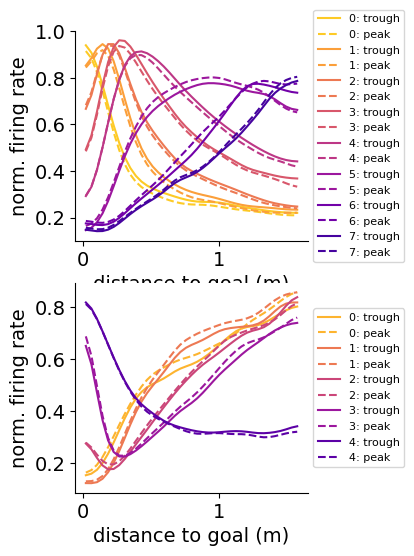

In [8]:
f, axes = plt.subplots(2, 1, figsize=(3, 6))
for ax, sign, neuron_groups in zip(axes, ["pos", "neg"], [8, 5]):
    tmt.plot_heatmap_slices(
        tuning_curves,
        tuning_metrics,
        sign=sign,
        neuron_groups=neuron_groups,
        distance_groups=False,
        how="horizontal",
        cmap="plasma_r",
        ax=ax,
    )

t-test: t = -4.778, p = 0.002


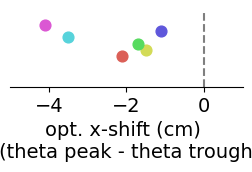

In [11]:
# random effects statistical test, how much to we need to shift peak and trough
# tuning curves to get them to align?
reload(tmt)
f, ax = plt.subplots(1, 1, figsize=(3, 1))
tmt.plot_subject_theta_x_shifts(ax=ax, print_stats=True)

In [17]:
# no clear anatomical organisation of distance tunned neurons across the medial wall
reload(pt)
sign = "pos"  # or "neg"
population_anatomy_df = pt.get_population_anatomy_df(sign=sign)

frames.navigation.parquet not found for m8.2022-07-26.maze
frames.spikeRates.parquet not found for m8.2022-07-26.maze
clusters.distanceTuningMetrics.parquet not found for m8.2022-07-26.maze


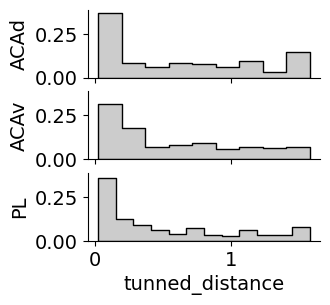

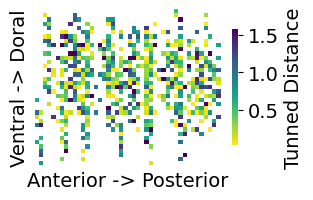

In [18]:
pt.plot_region_distance_tuning_distributions(population_anatomy_df)
pt.plot_voxel_distance_tuning_heatmap(population_anatomy_df)

## Unit Match

In [3]:
import numpy as np
from GridMaze.analysis.core import get_clusters as gc
from GridMaze.analysis.unit_match import get_across_maze_matches as mm
from GridMaze.analysis.unit_match import distance_to_goal as um_dtg

In [4]:
# get matches like this
matched_clusters = mm.get_cross_maze_matches(
    subject_ID="m2",
    maze_pair=("maze_1", "maze_2"),
    single_units=True,
    tuning_metric="distance_to_goal",
    min_split_half_corr=0.3,  # only keep matches that a both distance tuned to start with
    return_as="cluster_objects",
    verbose=True,
)

Found 260 matches for m2, maze_1.maze_2, with the given criteria.


In [5]:
# I've selected a few matched clusters from the above list that we can have a look at ...
_select_clusters = np.array(
    [
        ["m2.2022-07-05.maze_cluster64", "m2.2022-07-11.maze_cluster49"],  # Maze_1, Maze_2
        ["m2.2022-07-03.maze_cluster90", "m2.2022-07-11.maze_cluster94"],
        ["m2.2022-07-05.maze_cluster28", "m2.2022-07-11.maze_cluster26"],
        ["m2.2022-07-04.maze_cluster86", "m2.2022-07-12.maze_cluster84"],
        ["m2.2022-07-05.maze_cluster44", "m2.2022-07-13.maze_cluster65"],
        ["m2.2022-07-02.maze_cluster87", "m2.2022-07-09.maze_cluster91"],
    ]
)

select_clusters = np.array([[gc.get_cluster(C) for C in pair] for pair in _select_clusters])

Text(0, 0.5, 'Firing Rate (Hz)')

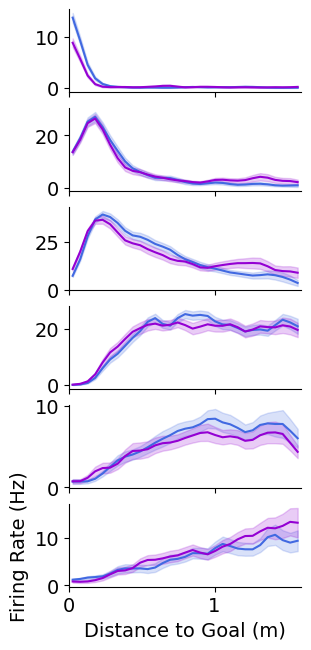

In [6]:
# set up fig for plotting matched clusters
f, axes = plt.subplots(6, 1, figsize=(3, 7.5), sharex=True)
for ax in axes:
    ax.spines[["top", "right"]].set_visible(False)

# plot matched cluster tuning curves on the same axis :)
for ax, pair in zip(axes, select_clusters):
    for Clust, color in zip(pair, ["royalblue", "darkviolet"]):
        Clust.plot_tuning(
            feature="distance_to_goal",
            ax=ax,
            feature_kwargs={"color": color},
        )
        ax.set_xlabel("")
        ax.set_ylabel("")
axes[-1].set_xlabel("Distance to Goal (m)")
axes[-1].set_ylabel("Firing Rate (Hz)")

In [8]:
reload(um_dtg)
matched_tuning_dfs = um_dtg.get_matched_distance_tuning_dfs(verbose=False)

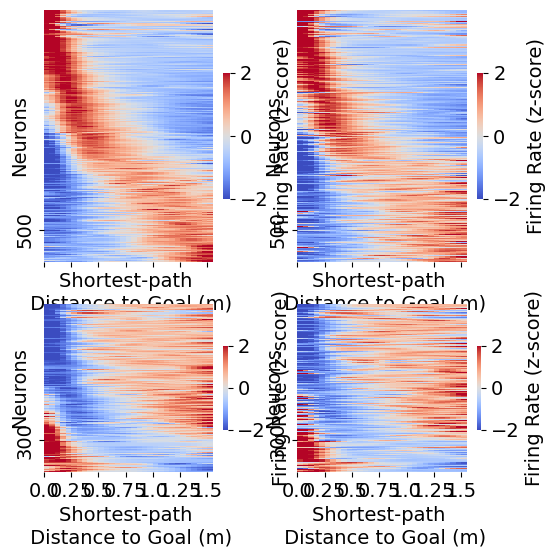

In [9]:
um_dtg.plot_matched_distance_tuning_heatmaps(*matched_tuning_dfs)

Subject p-values:
   p_value
m2     0.0
m3     0.0
m4     0.0
m6     0.0
m7     0.0
m8     0.0
Random effects t-statistic: 6.549, p-value: 0.001
Subject p-values:
   p_value
m2     0.0
m3     0.0
m4   0.393
m6     0.0
m7     0.0
m8   0.021
Random effects t-statistic: 4.740, p-value: 0.005


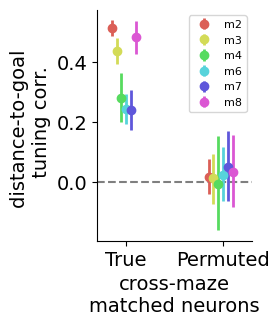

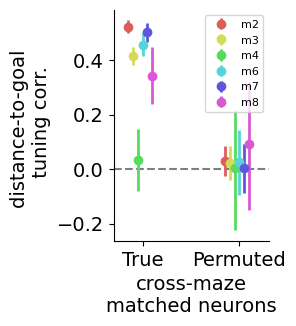

In [10]:
maze_pairs = [("maze_1", "maze_2"), ("maze_2", "rooms_maze")]
for maze_pair in maze_pairs:
    results = um_dtg.get_cross_maze_corr_summary(maze_pair, verbose=False)
    um_dtg.plot_cross_maze_corrs_summary(results, print_stats=True)